# VIHEPAT : évaluation de la chaîne « note vocale → priorité d'alerte »

[![Ouvrir dans Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yantekouarabiatou/-vihepat/blob/feat/circuit-soignant/ia/VIHEPAT_evaluation_IA.ipynb)

**Question.** Le patient décrit ses symptômes à voix haute. Pour prévenir la bonne équipe au bon moment, l'application doit classer ce message en **banal / à surveiller / alerte**. Quelle méthode classe le mieux, et pour quel coût ?

**Ce que nous comparons** sur le même jeu de 165 messages :

| | Modèle | Ce qu'il fait | Propre à l'équipe ? |
|---|---|---|---|
| A | Mots-clés + règles | lexique + négations → champs → moteur de règles | oui, 100 % hors ligne |
| B | TF-IDF + régression logistique | apprend directement texte → niveau (validation croisée) | oui, entraîné ici |
| C | Gemini 3.5 Flash-Lite + règles | le LLM extrait les champs, **le moteur de règles décide** | prompt, schéma, évaluation |
| D | Gemini 3.8 Flash + règles | idem, modèle plus gros (avec raisonnement) | prompt, schéma, évaluation |

Choix de conception : Gemini **n'attribue jamais la priorité**. Il remplit un schéma JSON fermé ; le niveau est calculé par le moteur de règles déterministe de l'application (`frontend/src/lib/triage.ts`), le même qui tourne hors ligne sur le téléphone. Cela rend chaque décision explicable (« alerte : fièvre depuis plus d'une semaine ») et vérifiable.

**Métrique principale : le sous-triage** (prédire un niveau plus bas que le bon). C'est l'erreur dangereuse : une alerte classée « banal » n'est pas transmise en priorité. Le sur-triage coûte du temps soignant, pas une vie.

**Reproductibilité.** Toutes les réponses de Gemini sont enregistrées dans `ia/resultats/*.jsonl` (réponse brute, latence, tokens, version exacte du modèle, erreurs). Sans clé API, le notebook recalcule tous les chiffres à partir de ces fichiers ; avec une clé, il peut refaire les appels (`REFAIRE_APPELS = True`).

## 0. Installation (Colab ou local)

In [1]:
import sys, os, subprocess
from pathlib import Path

EN_COLAB = "google.colab" in sys.modules
DEPOT = "https://github.com/yantekouarabiatou/-vihepat.git"
BRANCHE = "feat/circuit-soignant"

if EN_COLAB and not Path("vihepat").exists():
    subprocess.run(["git", "clone", "--depth", "1", "-b", BRANCHE, DEPOT, "vihepat"], check=True)
IA = next(p for p in [Path.cwd(), Path.cwd() / "ia", Path("vihepat/ia")] if (p / "vihepat_ia").exists()).resolve()
if EN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(IA / "requirements.txt")], check=True)
sys.path.insert(0, str(IA))

# Clé API : facultative (secrets Colab « GEMINI_API_KEY », ou variable d'environnement)
if EN_COLAB and not os.environ.get("GEMINI_API_KEY"):
    try:
        from google.colab import userdata
        os.environ["GEMINI_API_KEY"] = userdata.get("GEMINI_API_KEY")
    except Exception:
        pass
REFAIRE_APPELS = False  # True : complète / refait les appels manquants (coût réel, quelques centimes)
print("Dossier ia :", IA, "| clé API présente :", bool(os.environ.get("GEMINI_API_KEY")))

Dossier ia : C:\wamp64\www\Vihepat\ia | clé API présente : False


In [2]:
import json, time, platform
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import f1_score, accuracy_score, recall_score, cohen_kappa_score, confusion_matrix
from statsmodels.stats.contingency_tables import mcnemar
import jiwer, sklearn

from vihepat_ia.triage_rules import evaluer_triage, niveau_depuis_extraction, NIVEAUX, ORDRE, SYMPTOMES, SIGNES_GRAVES
from vihepat_ia.baseline_mots_cles import extraire as extraire_mots_cles
from vihepat_ia import gemini as G

import warnings
# Petits sous-groupes (ex. une langue sans alerte) : métriques indéfinies affichées NaN, sans avertissement
warnings.filterwarnings("ignore", category=RuntimeWarning, module="numpy")
warnings.filterwarnings("ignore", module="sklearn")

GRAINE = 42
rng = np.random.default_rng(GRAINE)
pd.set_option("display.max_colwidth", 120)
print("Python", platform.python_version(), "| scikit-learn", sklearn.__version__, "| prompt", G.PROMPT["version"])

# Couleurs : 4 premiers emplacements d'une palette catégorielle validée (daltonisme), dans un ordre fixe
COULEURS = {"A · mots-clés": "#2a78d6", "B · TF-IDF": "#eb6834", "C · Gemini Flash-Lite": "#1baf7a", "D · Gemini Flash": "#eda100"}
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": .25,
                     "font.size": 10, "figure.dpi": 110})

Python 3.13.2 | scikit-learn 1.9.1 | prompt extraction-v1


## 1. Les données

**Origine.** 165 messages de patients **fictifs** (vignettes) rédigés par l'équipe en français parlé au Bénin : expressions locales (« corps chaud », « ventre qui coule »), fautes d'orthographe, hésitations, négations, messages hors sujet, signes de gravité dits de façon indirecte. **Aucune donnée réelle de patient** n'a été utilisée.

**Annotation.** Pour chaque message, l'équipe a noté les champs attendus (symptômes, durée, intensité, signes de gravité) selon un guide écrit *avant* les essais (même définitions que les boutons de l'application). Le niveau attendu = moteur de règles appliqué à ces champs. On évalue donc **la compréhension du message**, à moteur de règles constant.

**Ce que ce jeu ne prouve pas** : la justesse clinique des règles elles-mêmes (à faire valider par des médecins), ni la performance sur de vrais patients. Voir section 9.

In [3]:
vignettes = [json.loads(l) for l in (IA / "data" / "vignettes.jsonl").read_text(encoding="utf-8").splitlines()]
df = pd.DataFrame(vignettes).set_index("id")
df["niveau_or"] = [niveau_depuis_extraction(v, v["traitement_recent"]) for v in vignettes]
df["mots"] = df.texte.str.split().str.len()
print(len(df), "messages |", df.mots.median(), "mots en médiane (min", df.mots.min(), ", max", df.mots.max(), ")")
display(pd.crosstab(df.cat, df.niveau_or, margins=True, margins_name="total")[NIVEAUX + ["total"]])

165 messages | 14.0 mots en médiane (min 6 , max 26 )


niveau_or,banal,a_surveiller,alerte,total
cat,,,,
bruit,9,3,3,15
familier,9,14,7,30
indirect,0,0,13,13
multi,4,7,11,22
negation,12,8,1,21
standard,15,14,10,39
urgence,0,0,25,25
total,49,46,70,165


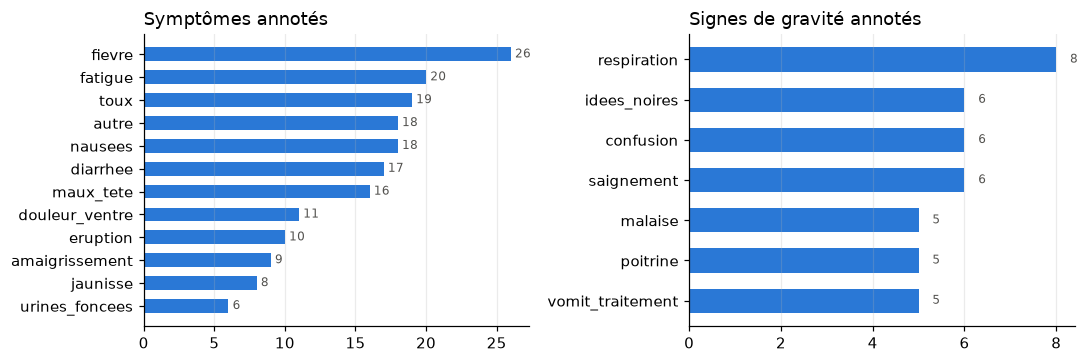

Champs non précisés par le patient : durée 0.1 | intensité 0.51


In [4]:
freq = Counter(s for l in df.symptomes for s in l)
freq_g = Counter(s for l in df.signes_graves for s in l)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
for a, f, titre in [(ax[0], freq, "Symptômes annotés"), (ax[1], freq_g, "Signes de gravité annotés")]:
    k = sorted(f, key=f.get)
    a.barh(k, [f[x] for x in k], color="#2a78d6", height=.6)
    a.set_title(titre, loc="left"); a.grid(axis="y", visible=False)
    for i, x in enumerate(k): a.text(f[x] + .3, i, f[x], va="center", fontsize=8, color="#52514e")
plt.tight_layout(); plt.show()
print("Champs non précisés par le patient : durée", (df.duree == "inconnue").mean().round(2), "| intensité", (df.intensite == "inconnue").mean().round(2))

## 2. Le moteur de règles du notebook est bien celui de l'application

Le moteur est écrit en TypeScript dans l'application et porté en Python ici. Pour vérifier le portage, 5 000 combinaisons aléatoires (graine fixe) ont été évaluées par la version TypeScript (`npm run ia:parite` dans `backend/`) puis comparées.

In [5]:
cas = json.loads((IA / "data" / "parite_ts.json").read_text())
diff = [c for c in cas if evaluer_triage(set(c["symptomes"]), c["duree"], c["intensite"], c["signesGraves"], c["traitementRecent"])[0] != c["niveau"]]
print(f"{len(cas)} cas comparés, {len(diff)} divergence(s) entre TypeScript et Python")
assert not diff

5000 cas comparés, 0 divergence(s) entre TypeScript et Python


## 3. Modèle A : mots-clés + règles (référence sans IA générative)

Lexique de symptômes, d'expressions locales et de signes de gravité, avec une gestion simple des négations (« pas de fièvre »). Il reprend le même vocabulaire familier que celui donné à Gemini.

⚠️ **Biais en sa faveur** : ce lexique a été écrit par la même équipe que les vignettes, en les connaissant. Son score ici est un **plafond optimiste** ; sur des messages nouveaux, il baisserait.

In [6]:
t0 = time.perf_counter()
ext_A = {i: extraire_mots_cles(t) for i, t in df.texte.items()}
lat_A_ms = (time.perf_counter() - t0) * 1000 / len(df)
df["pred_A"] = [niveau_depuis_extraction(ext_A[i], df.traitement_recent[i]) for i in df.index]
print(f"Latence moyenne : {lat_A_ms:.3f} ms par message (sur ce PC, sans réseau)")

Latence moyenne : 1.073 ms par message (sur ce PC, sans réseau)


## 4. Modèle B : TF-IDF + régression logistique (apprentissage supervisé)

Il apprend **directement** texte → niveau, sans passer par les champs. Avec 165 exemples, on l'évalue par **validation croisée stratifiée à 5 plis, répétée 20 fois** (chaque message est prédit par un modèle qui ne l'a pas vu). Hyperparamètres fixés a priori (pas de recherche, pour ne pas sur-ajuster sur un si petit jeu).

In [7]:
from sklearn.pipeline import make_pipeline, make_union
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict

def modele_B():
    return make_pipeline(
        make_union(TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), sublinear_tf=True, strip_accents="unicode"),
                   TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, strip_accents="unicode")),
        LogisticRegression(C=10, class_weight="balanced", max_iter=2000))

# Le contexte « traitement récent » vient du dossier, pas du message : on le donne au modèle comme un mot
X = (df.texte + np.where(df.traitement_recent, " TRAITEMENTRECENT", "")).values
y = df.niveau_or.values
scores_rep = []
for r in range(20):
    p = cross_val_predict(modele_B(), X, y, cv=StratifiedKFold(5, shuffle=True, random_state=r))
    scores_rep.append((accuracy_score(y, p), f1_score(y, p, average="macro")))
    if r == 0: df["pred_B"] = p
scores_rep = np.array(scores_rep)
print(f"Exactitude {scores_rep[:,0].mean():.3f} ± {scores_rep[:,0].std():.3f} | F1 macro {scores_rep[:,1].mean():.3f} ± {scores_rep[:,1].std():.3f}  (20 répétitions)")

m = modele_B().fit(X, y)
t0 = time.perf_counter(); m.predict(X); lat_B_ms = (time.perf_counter() - t0) * 1000 / len(X)
print(f"Latence moyenne d'inférence : {lat_B_ms:.3f} ms par message")

Exactitude 0.662 ± 0.027 | F1 macro 0.644 ± 0.028  (20 répétitions)


Latence moyenne d'inférence : 0.587 ms par message


## 5. Modèles C et D : Gemini comme extracteur + moteur de règles

**Prompt** (`backend/src/ia/extraction.json`, version `extraction-v1`, le même fichier que l'application) :
- *instruction système* : rôle limité à l'extraction, 6 règles (ne rien inventer, respecter les négations, signes de gravité même indirects, définitions de la durée et de l'intensité identiques aux boutons de l'application, « autre » + précision, aucun diagnostic) et un petit lexique local ;
- *sortie contrainte* : `responseMimeType = application/json` + `responseSchema` à listes fermées (le modèle ne peut pas répondre hors des catégories) ;
- *paramètres* : `temperature = 0` (réponses aussi stables que possible), pas d'exemples (zero-shot).

Le prompt a été figé **avant** la première exécution sur ce jeu ; il n'a pas été retouché d'après les résultats.

Les appels sont faits **un par un, sans nouvelle tentative automatique** dans la mesure : chaque échec (surcharge 503, délai) est journalisé. Un message en échec est retenté plus tard (3 essais max), ce qui permet de mesurer aussi la **fiabilité du service**.

In [8]:
MODELES = {"C": "gemini-3.5-flash-lite", "D": "gemini-3.8-flash"}
if REFAIRE_APPELS:
    for modele in MODELES.values():
        G.evaluer(vignettes, modele, IA / "resultats" / f"{modele}__texte.jsonl")

res, journal = {}, {}
for k, modele in MODELES.items():
    res[k], journal[k] = G.charger(IA / "resultats" / f"{modele}__texte.jsonl")
    df[f"pred_{k}"] = [niveau_depuis_extraction(res[k][i]["extraction"], df.traitement_recent[i]) if i in res[k] else None for i in df.index]

lignes = []
for k, modele in MODELES.items():
    j = pd.DataFrame(journal[k])
    lignes.append({"modèle": modele, "version servie": ", ".join(sorted(j["version_modele"].dropna().unique())) if "version_modele" in j else "aucune réponse",
                   "appels": len(j), "réussis": int(j.ok.sum()), "taux de réussite par appel": round(j.ok.mean(), 3),
                   "messages couverts": f"{len(res[k])}/{len(df)}",
                   "erreurs": dict(Counter(j.erreur.dropna())),
                   "dernier message d'erreur": (j[~j.ok].message.dropna().iloc[-1][:110] if "message" in j and j[~j.ok].message.notna().any() else "")})
fiabilite = pd.DataFrame(lignes).set_index("modèle"); fiabilite

,version servie,appels,réussis,taux de réussite par appel,messages couverts,erreurs,dernier message d'erreur
modèle,,,,,,,
gemini-3.5-flash-lite,gemini-3.5-flash-lite,168,165,0.982,165/165,{'http_429': 3},"You exceeded your current quota, please check your plan and billing details. For more information on this erro"
gemini-3.8-flash,aucune réponse,63,0,0.000,0/165,"{'http_503': 8, 'http_429': 55}","You exceeded your current quota, please check your plan and billing details. For more information on this erro"


## 6. Résultats : priorité d'alerte

Pour une comparaison équitable, les modèles sont évalués sur **les mêmes messages** (ceux que tous les modèles Gemini retenus ont traités). Un modèle Gemini n'est retenu que s'il a répondu à au moins 30 messages ; sinon seule sa fiabilité (section 5) est rapportée. Intervalles de confiance à 95 % par bootstrap (2 000 tirages).

In [9]:
TOUS = {"A": "A · mots-clés", "B": "B · TF-IDF", "C": "C · Gemini Flash-Lite", "D": "D · Gemini Flash"}
GEMINI_OK = [k for k in MODELES if df[f"pred_{k}"].notna().sum() >= 30]
NOMS = {k: v for k, v in TOUS.items() if k in ("A", "B") or k in GEMINI_OK}
for k in MODELES:
    if k not in GEMINI_OK:
        print(f"⚠️ {TOUS[k]} exclu de la comparaison : {df[f'pred_{k}'].notna().sum()} réponse(s) obtenue(s) (voir fiabilité)")
commun = df.dropna(subset=[f"pred_{k}" for k in GEMINI_OK]).index
print(f"Modèles comparés : {list(NOMS.values())} | messages communs : {len(commun)}/{len(df)}")

def metriques(g, p):
    go, po = np.array([ORDRE[x] for x in g]), np.array([ORDRE[x] for x in p])
    return {"exactitude": np.mean(go == po), "F1 macro": f1_score(go, po, average="macro"),
            "rappel alerte": np.mean(po[go == 2] == 2), "sous-triage": np.mean(po < go), "sur-triage": np.mean(po > go),
            "kappa pondéré": cohen_kappa_score(go, po, weights="quadratic")}

def bootstrap(g, p, n=2000):
    import warnings
    g, p = np.asarray(g), np.asarray(p)
    with warnings.catch_warnings():  # tirages sans aucune alerte (petits sous-groupes) : métrique indéfinie, ignorée
        warnings.simplefilter("ignore")
        tirages = [metriques(g[i], p[i]) for i in (rng.integers(0, len(g), len(g)) for _ in range(n))]
    return {m: np.nanpercentile([t[m] for t in tirages], [2.5, 97.5]) for m in tirages[0]}

tab, ic = {}, {}
for k in NOMS:
    g, p = df.loc[commun, "niveau_or"].values, df.loc[commun, f"pred_{k}"].values
    tab[NOMS[k]], ic[NOMS[k]] = metriques(g, p), bootstrap(g, p)
resultats = pd.DataFrame(tab).T
affiche = resultats.copy().astype(object)
for nom in affiche.index:
    for m in affiche.columns:
        lo, hi = ic[nom][m]; affiche.loc[nom, m] = f"{resultats.loc[nom, m]:.3f} [{lo:.2f}–{hi:.2f}]"
affiche

⚠️ D · Gemini Flash exclu de la comparaison : 0 réponse(s) obtenue(s) (voir fiabilité)
Modèles comparés : ['A · mots-clés', 'B · TF-IDF', 'C · Gemini Flash-Lite'] | messages communs : 165/165


,exactitude,F1 macro,rappel alerte,sous-triage,sur-triage,kappa pondéré
A · mots-clés,0.867 [0.81–0.92],0.863 [0.80–0.91],0.871 [0.79–0.94],0.073 [0.04–0.12],0.061 [0.02–0.10],0.824 [0.72–0.90]
B · TF-IDF,0.667 [0.59–0.74],0.651 [0.57–0.72],0.771 [0.67–0.87],0.145 [0.09–0.21],0.188 [0.13–0.25],0.668 [0.55–0.76]
C · Gemini Flash-Lite,0.945 [0.91–0.98],0.944 [0.91–0.98],0.957 [0.91–1.00],0.024 [0.01–0.05],0.030 [0.01–0.06],0.922 [0.85–0.98]


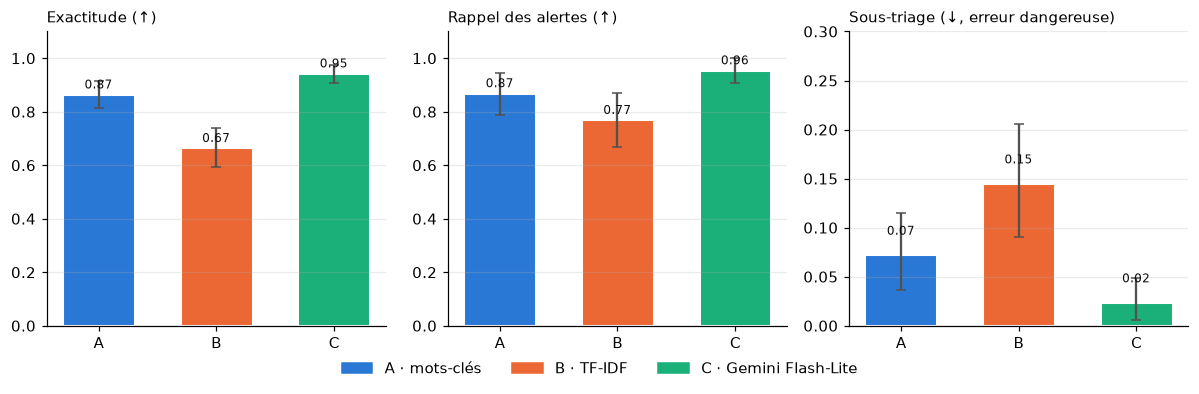

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), sharey=False)
for ax, m, titre in zip(axes, ["exactitude", "rappel alerte", "sous-triage"],
                        ["Exactitude (↑)", "Rappel des alertes (↑)", "Sous-triage (↓, erreur dangereuse)"]):
    noms = list(NOMS.values())
    v = [resultats.loc[n, m] for n in noms]
    err = np.array([[v[i] - ic[n][m][0], ic[n][m][1] - v[i]] for i, n in enumerate(noms)]).T
    ax.bar(range(len(noms)), v, color=[COULEURS[n] for n in noms], width=.62, yerr=err, capsize=3, ecolor="#52514e", edgecolor="white", linewidth=2)
    for i, x in enumerate(v): ax.text(i, x + .02, f"{x:.2f}", ha="center", fontsize=8, color="#0b0b0b")
    ax.set_xticks(range(len(noms)), [n.split(" · ")[0] for n in noms]); ax.set_title(titre, loc="left", fontsize=10)
    ax.set_ylim(0, 1.1 if m != "sous-triage" else max(.3, max(v) + .1)); ax.grid(axis="x", visible=False)
fig.legend([plt.Rectangle((0, 0), 1, 1, color=COULEURS[n]) for n in NOMS.values()], NOMS.values(), ncol=len(NOMS), loc="lower center", frameon=False, bbox_to_anchor=(.5, -.06))
plt.tight_layout(); plt.show()

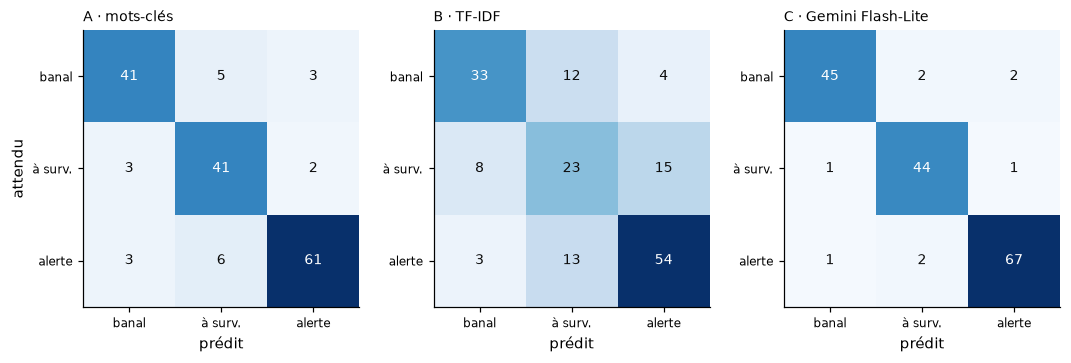

Sous la diagonale = sous-triage (dangereux) ; au-dessus = sur-triage.


In [11]:
fig, axes = plt.subplots(1, len(NOMS), figsize=(3.3 * len(NOMS), 3.2))
lib = ["banal", "à surv.", "alerte"]
for ax, (k, nom) in zip(axes, NOMS.items()):
    cm = confusion_matrix(df.loc[commun, "niveau_or"], df.loc[commun, f"pred_{k}"], labels=NIVEAUX)
    ax.imshow(cm, cmap="Blues", vmin=0); ax.grid(False)
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, v, ha="center", va="center", color="white" if v > cm.max() / 2 else "#0b0b0b", fontsize=9)
    ax.set_xticks(range(3), lib, fontsize=8); ax.set_yticks(range(3), lib, fontsize=8)
    ax.set_xlabel("prédit"); ax.set_title(nom, loc="left", fontsize=9)
axes[0].set_ylabel("attendu"); plt.tight_layout(); plt.show()
print("Sous la diagonale = sous-triage (dangereux) ; au-dessus = sur-triage.")

In [12]:
# Test de McNemar exact : les différences d'exactitude entre deux modèles sont-elles significatives ?
def mc(a, b):
    ok_a = df.loc[commun, f"pred_{a}"] == df.loc[commun, "niveau_or"]
    ok_b = df.loc[commun, f"pred_{b}"] == df.loc[commun, "niveau_or"]
    t = [[int((ok_a & ok_b).sum()), int((ok_a & ~ok_b).sum())], [int((~ok_a & ok_b).sum()), int((~ok_a & ~ok_b).sum())]]
    return {"paire": f"{a} vs {b}", "seul le 1er juste": t[0][1], "seul le 2e juste": t[1][0], "p (McNemar exact)": round(mcnemar(t, exact=True).pvalue, 4)}
paires = [(a, b) for a, b in [("C", "A"), ("C", "B"), ("D", "A"), ("D", "C"), ("A", "B")] if a in NOMS and b in NOMS]
pd.DataFrame([mc(a, b) for a, b in paires])

,paire,seul le 1er juste,seul le 2e juste,p (McNemar exact)
0,C vs A,20,7,0.0192
1,C vs B,52,6,0.0000
2,A vs B,46,13,0.0000


In [13]:
# Par type de message : où chaque méthode décroche
par_cat = pd.DataFrame({NOMS[k]: (df.loc[commun, f"pred_{k}"] == df.loc[commun, "niveau_or"]).groupby(df.loc[commun, "cat"]).mean() for k in NOMS})
par_cat.insert(0, "n", df.loc[commun].groupby("cat").size())
par_cat.round(2)

,n,A · mots-clés,B · TF-IDF,C · Gemini Flash-Lite
cat,,,,
bruit,15,0.67,0.53,0.93
familier,30,0.80,0.50,0.90
indirect,13,0.92,0.85,0.92
multi,22,0.91,0.77,1.00
negation,21,0.86,0.48,1.00
standard,39,0.97,0.69,0.95
urgence,25,0.84,0.88,0.92


## 7. Qualité de l'extraction champ par champ (A, C, D)

In [14]:
def prf(gold, pred):
    tp = sum(len(set(g) & set(p)) for g, p in zip(gold, pred)); fp = sum(len(set(p) - set(g)) for g, p in zip(gold, pred))
    fn = sum(len(set(g) - set(p)) for g, p in zip(gold, pred))
    pr = tp / (tp + fp) if tp + fp else 1.0; rc = tp / (tp + fn) if tp + fn else 1.0
    return pr, rc, 2 * pr * rc / (pr + rc) if pr + rc else 0.0

lignes = []
sources = {"A": {i: ext_A[i] for i in commun}, **{k: {i: res[k][i]["extraction"] for i in commun} for k in GEMINI_OK}}
for k, ext in sources.items():
    for champ in ["symptomes", "signes_graves"]:
        pr, rc, f1 = prf([df.loc[i, champ] for i in commun], [ext[i].get(champ, []) for i in commun])
        lignes.append({"modèle": NOMS[k], "champ": champ, "précision": pr, "rappel": rc, "F1": f1})
    for champ in ["duree", "intensite"]:
        acc = np.mean([ext[i].get(champ) == df.loc[i, champ] for i in commun])
        lignes.append({"modèle": NOMS[k], "champ": champ, "précision": np.nan, "rappel": np.nan, "F1": acc})
extraction = pd.DataFrame(lignes).pivot(index="champ", columns="modèle", values="F1").round(3)
print("F1 (symptômes, signes de gravité) ou exactitude (durée, intensité)"); extraction

F1 (symptômes, signes de gravité) ou exactitude (durée, intensité)


modèle,A · mots-clés,C · Gemini Flash-Lite
champ,,
duree,0.933,0.939
intensite,0.927,0.958
signes_graves,0.864,0.894
symptomes,0.939,0.951


In [15]:
# Rappel des signes de gravité, signe par signe : un signe raté = une urgence manquée
lignes = []
for g in SIGNES_GRAVES:
    porteurs = [i for i in commun if g in df.loc[i, "signes_graves"]]
    lignes.append({"signe": g, "n": len(porteurs), **{NOMS[k]: np.mean([g in sources[k][i].get("signes_graves", []) for i in porteurs]) if porteurs else np.nan for k in sources}})
pd.DataFrame(lignes).set_index("signe").round(2)

,n,A · mots-clés,C · Gemini Flash-Lite
signe,,,
respiration,8,0.62,1.00
poitrine,5,1.00,1.00
confusion,6,0.83,0.83
vomit_traitement,5,0.80,1.00
saignement,6,1.00,0.67
malaise,5,1.00,1.00
idees_noires,6,0.83,1.00


## 8. La voix : transcription puis priorité (sous-corpus audio)

42 messages (un sur quatre) ont été lus par 3 voix de synthèse françaises (Windows : Hortense, Julie, Paul) puis encodés en WebM/Opus 24 kb/s, **le format qu'envoie Chrome** depuis l'application. Gemini reçoit l'audio directement (transcription + extraction en un seul appel).

On mesure : le **taux d'erreur de mots (WER)** de la transcription, l'exactitude du niveau, et la latence. Limite forte : une voix de synthèse est plus nette qu'un patient réel (accent, bruit, débit) ; ces chiffres sont un **plafond**.

In [16]:
if REFAIRE_APPELS:
    ids_audio = {p.stem for p in (IA / "data" / "audio").glob("*.webm")}
    for modele in MODELES.values():
        G.evaluer([v for v in vignettes if v["id"] in ids_audio], modele, IA / "resultats" / f"{modele}__audio.jsonl",
                  modalite="audio", dossier_audio=IA / "data" / "audio")

norm = jiwer.Compose([jiwer.ToLowerCase(), jiwer.RemovePunctuation(), jiwer.RemoveMultipleSpaces(), jiwer.Strip(), jiwer.ReduceToListOfListOfWords()])
lignes, res_audio = [], {}
for k, modele in MODELES.items():
    f = IA / "resultats" / f"{modele}__audio.jsonl"
    if not f.exists(): continue
    ok, jr = G.charger(f); res_audio[k] = ok
    ids = sorted(ok)
    pred = [niveau_depuis_extraction(ok[i]["extraction"], df.traitement_recent[i]) for i in ids]
    wer = jiwer.wer([df.texte[i] for i in ids], [ok[i]["extraction"]["transcription"] for i in ids], reference_transform=norm, hypothesis_transform=norm)
    lat = np.array([ok[i]["latence_ms"] for i in ids])
    m = metriques(df.loc[ids, "niveau_or"].values, np.array(pred))
    m_txt = metriques(df.loc[ids, "niveau_or"].values, df.loc[ids, f"pred_{k}"].values) if df.loc[ids, f"pred_{k}"].notna().all() else {}
    lignes.append({"modèle": modele, "messages": f"{len(ids)}/42", "taux réussite appel": round(pd.DataFrame(jr).ok.mean(), 3),
                   "WER": round(wer, 3), "exactitude niveau (audio)": round(m["exactitude"], 3),
                   "même messages en texte": round(m_txt.get("exactitude", np.nan), 3),
                   "sous-triage (audio)": round(m["sous-triage"], 3),
                   "latence médiane (s)": round(np.median(lat) / 1000, 2), "latence p95 (s)": round(np.percentile(lat, 95) / 1000, 2),
                   "tokens audio moyens": round(np.mean([ok[i]["tokens_audio"] for i in ids]))})
audio = pd.DataFrame(lignes).set_index("modèle"); audio

,messages,taux réussite appel,WER,exactitude niveau (audio),même messages en texte,sous-triage (audio),latence médiane (s),latence p95 (s),tokens audio moyens
modèle,,,,,,,,,
gemini-3.5-flash-lite,42/42,0.977,0.049,0.952,0.952,0.024,3.45,32.17,124


## 8 bis. Vraies voix : français avec accent béninois, et fon

Des membres de l'équipe (locuteurs `L1`, `L2`… ; aucun nom n'est conservé) ont redit 30 messages du jeu (10 par niveau, tirés au hasard avec une graine fixe : `scripts/preparer_enregistrements.py`) :
- en **français**, en lisant la phrase avec leur accent : on peut mesurer le WER ;
- en **fon**, en traduisant tout le sens (négations et détails hors sujet compris) : l'annotation du message reste valable, on mesure donc la priorité et les champs. **Pas de WER en fon** : il faudrait une transcription de référence écrite par un locuteur, et la graphie du fon varie.

Enregistrements faits au téléphone (notes WhatsApp, mémos vocaux), convertis en WebM/Opus comme dans l'application (`scripts/importer_enregistrements.py`). Même prompt `extraction-v1`, non modifié pour le fon.

In [17]:
man_f = IA / "data" / "enregistrements" / "manifeste.json"
cache_reel = IA / "resultats" / f"{MODELES['C']}__reel.jsonl"
if REFAIRE_APPELS and man_f.exists():
    G.evaluer([{"id": m["fichier"]} for m in json.loads(man_f.read_text(encoding="utf-8"))], MODELES["C"], cache_reel,
              modalite="audio", dossier_audio=IA / "data" / "enregistrements" / "audio")

reel = pd.DataFrame()
if not (man_f.exists() and cache_reel.exists()):
    print("Pas encore de vraies notes vocales évaluées : voir ia/data/enregistrements/README.md")
else:
    ok_reel, journal_reel = G.charger(cache_reel)
    lignes = []
    for m in json.loads(man_f.read_text(encoding="utf-8")):
        r, v = ok_reel.get(m["fichier"]), df.loc[m["vignette"]]
        x = r["extraction"] if r else {}
        lignes.append({**m, "ok": r is not None, "niveau_or": v.niveau_or,
                       "pred": niveau_depuis_extraction(x, v.traitement_recent) if r else None,
                       "pred_texte": v.pred_C, "langue_detectee": x.get("langue"), "transcription": x.get("transcription"),
                       "symp_or": v.symptomes, "symp": x.get("symptomes", []), "graves_or": v.signes_graves,
                       "graves": x.get("signes_graves", []), "latence_ms": r["latence_ms"] if r else None})
    reel = pd.DataFrame(lignes)
    resume = []
    for langue, g in reel.groupby("langue"):
        g_ok = g[g.ok]
        m = metriques(g_ok.niveau_or.values, g_ok.pred.values); b = bootstrap(g_ok.niveau_or.values, g_ok.pred.values)
        ligne = {"langue": langue, "notes": len(g), "locuteurs": g.locuteur.nunique(), "analysées": len(g_ok),
                 "exactitude": f"{m['exactitude']:.3f} [{b['exactitude'][0]:.2f}–{b['exactitude'][1]:.2f}]",
                 "mêmes messages en texte": round(np.mean(g_ok.pred_texte == g_ok.niveau_or), 3),
                 "sous-triage": round(m["sous-triage"], 3), "rappel alerte": round(m["rappel alerte"], 3),
                 "F1 symptômes": round(prf(g_ok.symp_or, g_ok.symp)[2], 3), "rappel signes graves": round(prf(g_ok.graves_or, g_ok.graves)[1], 3),
                 "langue détectée": dict(Counter(g_ok.langue_detectee)),
                 "latence médiane (s)": round(g_ok.latence_ms.median() / 1000, 2)}
        if langue == "fr":
            ligne["WER"] = round(jiwer.wer([df.texte[v] for v in g_ok.vignette], list(g_ok.transcription),
                                           reference_transform=norm, hypothesis_transform=norm), 3)
        resume.append(ligne)
    vraies_voix = pd.DataFrame(resume).set_index("langue")
    display(vraies_voix)
    print("Taux de réussite des appels :", round(pd.DataFrame(journal_reel).ok.mean(), 3))

,notes,locuteurs,analysées,exactitude,mêmes messages en texte,sous-triage,rappel alerte,F1 symptômes,rappel signes graves,langue détectée,latence médiane (s),WER
langue,,,,,,,,,,,,
fon,9,1,9,0.000 [0.00–0.00],1.0,1.0,0.0,0.000,0.0,{'fon': 9},3.23,NaN
fr,9,1,9,1.000 [1.00–1.00],1.0,0.0,1.0,0.947,1.0,{'fr': 9},2.97,0.144


Taux de réussite des appels : 1.0


In [18]:
# Transcriptions produites à partir du fon : à faire relire par un locuteur fon (la machine peut « inventer » une traduction)
if len(reel) and (reel.langue == "fon").any():
    display(reel[reel.langue == "fon"][["fichier", "niveau_or", "pred", "langue_detectee", "transcription"]])
    erreurs_fon = reel[(reel.langue == "fon") & reel.ok & (reel.pred.map(lambda p: ORDRE.get(p, 0)) < reel.niveau_or.map(ORDRE))]
    print(f"Sous-triages en fon : {len(erreurs_fon)}"); display(erreurs_fon[["fichier", "niveau_or", "pred", "transcription"]])

,fichier,niveau_or,pred,langue_detectee,transcription
0,fon_L1_V016,alerte,banal,fon,"No zozodo é di, ékobllo wazantonton, ékado tɔyu wé déboa."
1,fon_L1_V039,alerte,banal,fon,Vi vi nosomi Tabi noso non ja te ke non dio ce ya sa tondi
2,fon_L1_V097,alerte,a_surveiller,fon,C'est un peu un peu tu as des gros cadeaux violé manoté. On qu'il y a des nazé bon dos tu as des un bien fort.
3,fon_L1_V098,alerte,banal,fon,"M'fon mongbe dokomè do pati m'ni, m'kasse ro ti m'ni de ingban."
4,fon_L1_V103,alerte,banal,fon,"Mɔ̀ cɛ́ sá àgbɔ̌ ɖò vì vì xì xɛ̀n nɛ́ ĩ̀ ɔ́, mɔ̀ ɖò kànfɔ̀ ɖɔmǐ, mɔ̀ sɔ́ sǐ blɔ̌ ɖɛ́ à."
5,fon_L1_V125,alerte,banal,fon,Kouto bada klemende toran soupa ndoudou da rohmen doumou mi sinzanton diye nseoussa ndeboa
6,fon_L1_V126,alerte,banal,fon,Non dé lètɔ ɖò gbasaji wǒ sin sɔ.
7,fon_L1_V148,alerte,a_surveiller,fon,"MÃ´ kountÃ© dji alor pas po ti choun, mon non kolo agbazati tau, sin azafoton diÃ©."
8,fon_L1_V161,alerte,banal,fon,Nɔɔ si xò bo wɛ gànji à? Ŋu mɛ léìn. Ayi gbadé gbadé nɔnɔ. Se à sɛntɔ dié.


Sous-triages en fon : 9


,fichier,niveau_or,pred,transcription
0,fon_L1_V016,alerte,banal,"No zozodo é di, ékobllo wazantonton, ékado tɔyu wé déboa."
1,fon_L1_V039,alerte,banal,Vi vi nosomi Tabi noso non ja te ke non dio ce ya sa tondi
2,fon_L1_V097,alerte,a_surveiller,C'est un peu un peu tu as des gros cadeaux violé manoté. On qu'il y a des nazé bon dos tu as des un bien fort.
3,fon_L1_V098,alerte,banal,"M'fon mongbe dokomè do pati m'ni, m'kasse ro ti m'ni de ingban."
4,fon_L1_V103,alerte,banal,"Mɔ̀ cɛ́ sá àgbɔ̌ ɖò vì vì xì xɛ̀n nɛ́ ĩ̀ ɔ́, mɔ̀ ɖò kànfɔ̀ ɖɔmǐ, mɔ̀ sɔ́ sǐ blɔ̌ ɖɛ́ à."
5,fon_L1_V125,alerte,banal,Kouto bada klemende toran soupa ndoudou da rohmen doumou mi sinzanton diye nseoussa ndeboa
6,fon_L1_V126,alerte,banal,Non dé lètɔ ɖò gbasaji wǒ sin sɔ.
7,fon_L1_V148,alerte,a_surveiller,"MÃ´ kountÃ© dji alor pas po ti choun, mon non kolo agbazati tau, sin azafoton diÃ©."
8,fon_L1_V161,alerte,banal,Nɔɔ si xò bo wɛ gànji à? Ŋu mɛ léìn. Ayi gbadé gbadé nɔnɔ. Se à sɛntɔ dié.


## 8 ter. Piste fon : reconnaissance MMS + traduction NLLB-200, puis notre chaîne

Gemini seul ne comprend pas le fon (section 8 bis). On a testé des modèles spécialisés qui couvrent le fon : **MMS** (Meta, reconnaissance vocale, adaptateur « fon ») puis **NLLB-200** (Meta, traduction fon → français), avant l'extraction Gemini et le moteur de règles habituels. Exécuté sur Colab GPU : notebook `VIHEPAT_fon_MMS_NLLB.ipynb`, résultats dans `resultats/fon_mms_*.jsonl`.

« Pour la bonne raison » : le niveau est juste **et** le signe de gravité (ou symptôme) attendu a été trouvé, pour ne pas compter les réussites par hasard.

In [19]:
fichiers_fon = sorted((IA / "resultats").glob("fon_mms_*.jsonl"))
fon_pistes = pd.DataFrame()
if not fichiers_fon:
    print("Piste fon pas encore exécutée (VIHEPAT_fon_MMS_NLLB.ipynb sur Colab)")
else:
    def dernier_par_id(f):
        d = {}
        for l in f.read_text(encoding="utf-8").splitlines():
            x = json.loads(l); d[x["id"]] = x
        return d
    sources = {"Gemini seul (audio)": {k: v for k, v in (G.charger(cache_reel)[0] if cache_reel.exists() else {}).items() if k.startswith("fon_")}}
    for f in fichiers_fon:
        d = dernier_par_id(f)
        nom = next(iter(d.values()))["modeles"].replace("gemini-3.5-flash-lite", "Gemini")
        sources[nom] = d
    ids = sorted(set.intersection(*(set(s) for s in sources.values())))
    lignes = []
    for nom, src in sources.items():
        juste = raison_ok = sous = 0
        for i in ids:
            r = src[i]
            if not r.get("ok"): continue
            v = df.loc[i.split("_")[-1]]; x = r["extraction"]; p = niveau_depuis_extraction(x, v.traitement_recent)
            cles = set(v.signes_graves) or set(v.symptomes) - {"autre"}
            raison = bool(cles & (set(x["signes_graves"]) | set(x["symptomes"])))
            juste += p == v.niveau_or; raison_ok += p == v.niveau_or and raison; sous += ORDRE[p] < ORDRE[v.niveau_or]
        lignes.append({"méthode": nom, "notes fon": len(ids), "bien classées": juste, "pour la bonne raison": raison_ok,
                       "alertes sous-estimées": sous})
    fon_pistes = pd.DataFrame(lignes).set_index("méthode")
    display(fon_pistes)
    exemple = dernier_par_id(fichiers_fon[0])
    display(pd.DataFrame([{"note": i, "fiche": df.texte[i.split("_")[-1]], "MMS (fon)": exemple[i]["texte_fon"],
                           "traduction": exemple[i]["texte_fr"]} for i in ids]))

,notes fon,bien classées,pour la bonne raison,alertes sous-estimées
méthode,,,,
Gemini seul (audio),9,0,0,9
mms-1b-all:fon + nllb-200-distilled-600M + Gemini,9,3,2,6


,note,fiche,MMS (fon),traduction
0,fon_L1_V016,"J'ai la fièvre depuis plus d'une semaine, elle ne descend pas.",nnozozo ɖó wɛ jǐ é ko bló wa azǎn tantɔn é ka ɖo do yi wɛ ɖěbo a,il fait huit jours qu'il fait chaud et il ne se couche plus
1,fon_L1_V039,"Je rends les comprimés à chaque fois que je les prends, depuis trois jours.",vivínɔ sɔ́ mì kabǐ nɔ só nɔ unja atékɛ́ ɔ́ nú j ɔ́ sín azǎn tɔn ɖíe,"depuis le jour où j'ai été élevé, j'ai été élevé dans la montagne et j'ai été élevé dans la forêt"
2,fon_L1_V097,"Mes gencives saignent sans arrêt depuis hier, le mouchoir est plein de sang.",sín azǎn tɔnunɖí ɔ́ nyɔnkpo tín ce ɖo kanjɔvi ɛ ma nɔ te nkíja ɖěu nɔ zé bó nɔ ɖó te na ɔ́ bǐɛ fá,"depuis ce jour-là, mon sang est couché dans ma poitrine et tout le sang que j'ai porté s'est refroidi"
3,fon_L1_V098,"Je me suis réveillé par terre dans la douche, je ne sais pas ce qui s'est passé.",un fɔn mɔ nyiɖé ɖo kɔmɛ ɖo kpa ce mɛ un ka sexó tínmɛ ɖěe nyi gbɔn ǎ,j'ai manqué quelque chose dans ma tête et je n'ai rien expliqué
4,fon_L1_V103,"J'ai la diarrhée et des vomissements depuis quatre jours, je ne peux plus rien faire.",un ɖo sí sá wɛ bó ɖo víví ɛ sín ɛsɛ̌nnɛ ɖíe nmɔ ɖɔ ganvɔ́ dó mì un sɔ́ si bló un ɖe a,j'étais en train de pleurer et de lui plaire depuis que je l'ai vu et qu'il m'a dit que je ne l'avais pas fait avec ...
5,fon_L1_V125,"Bonsoir. Je suis au champ, il y a du vent. Je disais : mal au ventre depuis cinq jours, fort fort, je ne peux plus t...",kúdó gbada klemɛnɖe jɔhɔn sukpɔ́́ wɛn un ɖoɖudɔ ɔ́ɖɔ xómɛ ɖo wwwi mìɛ́ sín azǎn tɔ́n ɔ́n ɖíe un se xó sɔ́ wa nde bo a,"depuis le jour où je suis né, j'ai entendu le bruit d'un grand vent"
6,fon_L1_V126,svp jai des bouton partou depui hier apres le nouveau medicaman,nǔɖé lɛ́ tɔ́nɖɔ agbaza ce wó sín sɔ,il y a encore quelque chose qui m'a déchiré hier
7,fon_L1_V148,Ma peau a jauni et je gratte beaucoup depuis quinze jours.,nukún ce ɖyɔ́ alɔpa bó cí sonu bɔ nɔkló agbaza ce tawun sín azǎn fɔ tɔn ɖíe,mes yeux ont changé et j'ai souffert depuis le lendemain
8,fon_L1_V161,"Je n'arrive pas à respirer quand je suis couché, je dors assis depuis trois nuits.",nɔ sixó gbɔ jɛ gandya nú mláyi ayǐjɔ́njɔ́njé́n nɔ nɔ sín asǎn tɔn ɖíe,ma mère a été victime de violences violentes depuis longtemps


## 9. Latence et coût mesurés

Prix officiels relevés le **05/10/2026** sur https://ai.google.dev/gemini-api/docs/pricing (palier payant ; un palier gratuit existe pour les deux modèles) :

| Modèle | Entrée (texte et audio) | Sortie (raisonnement compris) |
|---|---|---|
| gemini-3.8-flash | 0,75 $ / M tokens (jusqu'au 31/12/2026, puis 1,50 $) | 3,75 $ / M (puis 7,50 $) |
| gemini-3.5-flash-lite | 0,30 $ / M | 2,50 $ / M |

Les latences sont mesurées depuis le PC de développement de l'équipe, sur sa connexion habituelle : elles incluent le réseau et varient selon la connexion du patient. Les tokens sont ceux renvoyés par l'API (`usageMetadata`).

In [20]:
PRIX = {"gemini-3.8-flash": (0.75, 3.75), "gemini-3.5-flash-lite": (0.30, 2.50)}  # $/M tokens, relevé du 05/10/2026
lignes = []
for k, modele in MODELES.items():
    for modalite, ok in [("texte", res.get(k, {})), ("audio", res_audio.get(k, {}))]:
        if not ok: continue
        d = pd.DataFrame(ok.values())
        cout = (d.tokens_entree * PRIX[modele][0] + (d.tokens_sortie + d.tokens_reflexion) * PRIX[modele][1]) / 1e6
        lignes.append({"modèle": modele, "entrée": modalite, "n": len(d),
                       "latence médiane (s)": round(d.latence_ms.median() / 1000, 2), "p95 (s)": round(d.latence_ms.quantile(.95) / 1000, 2),
                       "tokens entrée": round(d.tokens_entree.mean()), "tokens sortie": round(d.tokens_sortie.mean()),
                       "tokens raisonnement": round(d.tokens_reflexion.mean()),
                       "coût / 1 000 notes ($)": round(cout.mean() * 1000, 3)})
lignes += [{"modèle": "A · mots-clés", "entrée": "texte", "n": len(df), "latence médiane (s)": round(lat_A_ms / 1000, 6), "coût / 1 000 notes ($)": 0},
           {"modèle": "B · TF-IDF", "entrée": "texte", "n": len(df), "latence médiane (s)": round(lat_B_ms / 1000, 6), "coût / 1 000 notes ($)": 0}]
couts = pd.DataFrame(lignes).set_index(["modèle", "entrée"]); couts

n  latence médiane (s)  p95 (s)  \
modèle                entrée                                      
gemini-3.5-flash-lite texte   165             2.480000     3.83   
                      audio    42             3.450000    32.17   
A · mots-clés         texte   165             0.001073      NaN   
B · TF-IDF            texte   165             0.000587      NaN   

                              tokens entrée  tokens sortie  \
modèle                entrée                                 
gemini-3.5-flash-lite texte           544.0          104.0   
                      audio           655.0           98.0   
A · mots-clés         texte             NaN            NaN   
B · TF-IDF            texte             NaN            NaN   

                              tokens raisonnement  coût / 1 000 notes ($)  
modèle                entrée                                               
gemini-3.5-flash-lite texte                   0.0                   0.422  
                      audio                   0.0                   0.443  
A · mots-clés         texte                   NaN                   0.000  
B · TF-IDF            texte                   NaN                   0.000

## 10. Analyse d'erreurs : tous les sous-triages des modèles Gemini

In [21]:
lignes = []
for k in GEMINI_OK:
    for i in commun:
        g, p = df.loc[i, "niveau_or"], df.loc[i, f"pred_{k}"]
        if ORDRE[p] < ORDRE[g]:
            x = res[k][i]["extraction"]
            lignes.append({"modèle": k, "id": i, "texte": df.texte[i], "attendu": g, "prédit": p,
                           "attendu (champs)": f"{df.symptomes[i]} {df.duree[i]}/{df.intensite[i]} {df.signes_graves[i]}",
                           "extrait": f"{x['symptomes']} {x['duree']}/{x['intensite']} {x['signes_graves']}"})
pd.DataFrame(lignes) if lignes else print("Aucun sous-triage.")

,modèle,id,texte,attendu,prédit,attendu (champs),extrait
0,C,V079,"Il y a du sang dans mes selles, beaucoup, depuis ce matin.",alerte,banal,[] aujourdhui/inconnue ['saignement'],['autre'] aujourdhui/inconnue []
1,C,V092,"Mes règles coulent comme jamais depuis trois jours, je change de serviette toutes les heures.",alerte,a_surveiller,[] quelques_jours/inconnue ['saignement'],['autre'] quelques_jours/fort []
2,C,V141,"J'ai très mal à la tête depuis trois jours, je ne peux pas travailler.",a_surveiller,banal,['maux_tete'] quelques_jours/fort [],['maux_tete'] quelques_jours/gene []
3,C,V164,"Ma nuque est raide et j'ai de la fièvre forte depuis hier, la lumière me fait mal aux yeux.",alerte,a_surveiller,['fievre'] aujourdhui/fort ['confusion'],"['fievre', 'autre'] aujourdhui/fort []"


In [22]:
# Stabilité : même requête, température 0, plusieurs appels ont-ils donné la même extraction ?
for k in GEMINI_OK:
    j = pd.DataFrame(journal[k]); j = j[j.ok]
    rep = j.groupby("id").filter(lambda g: len(g) > 1)
    if len(rep):
        stables = rep.groupby("id").apply(lambda g: len({json.dumps({c: sorted(v) if isinstance(v, list) else v for c, v in e.items() if c not in ("transcription", "precision")}, sort_keys=True) for e in g.extraction}) == 1)
        print(MODELES[k], ":", f"{stables.mean():.0%} d'extractions identiques sur {len(stables)} messages appelés plusieurs fois")
    else:
        print(MODELES[k], ": aucun message appelé plusieurs fois avec succès (stabilité non mesurée ici)")

gemini-3.5-flash-lite : aucun message appelé plusieurs fois avec succès (stabilité non mesurée ici)


## 11. Conclusions, limites assumées et éthique

Les chiffres ci-dessus sont produits par l'exécution de ce notebook ; le résumé chiffré est dans `ia/RESULTATS.md` (régénéré par la dernière cellule).

**Limites (à dire au jury)**
1. **Données synthétiques** : 165 vignettes écrites par l'équipe, pas de vrais patients. Un vocabulaire plus riche ou plus local ferait baisser tous les scores, surtout celui du modèle A.
2. **Annotation par l'équipe**, sans double annotation ni validation médicale : l'accord inter-annotateurs n'est pas mesuré.
3. **Moteur de règles non validé cliniquement** : on mesure la compréhension du message, pas la pertinence médicale des seuils.
4. **Audio de synthèse** (accent de France, sans bruit) : WER et exactitude audio sont des plafonds.
5. **Fon** : mesuré seulement sur les notes de la section 8 bis (quelques locuteurs de l'équipe, messages fictifs). Aucun chiffre en fon n'est revendiqué au-delà de ce qui y est affiché ; les transcriptions fon doivent être relues par un locuteur.
6. **Petit échantillon** : intervalles de confiance larges (voir section 6) ; les écarts non significatifs au test de McNemar ne doivent pas être présentés comme des gains.
7. **Modèle « latest » mouvant** : on fixe des versions précises (`gemini-3.8-flash`, `gemini-3.5-flash-lite`), et chaque réponse garde la version servie.

**Biais**
- Le jeu est en français standard ou familier ; les patients peu à l'aise à l'écrit ou parlant surtout une langue nationale sont sous-représentés, donc l'outil risque de mieux servir les plus favorisés. Réponse dans l'application : le formulaire à pictogrammes et la lecture à voix haute restent toujours disponibles, et l'analyse vocale ne fait que **pré-remplir**.
- Erreurs asymétriques : on privilégie le rappel des alertes (sous-triage minimal) au prix d'alertes en trop.

**Confidentialité**
- L'audio est envoyé à Google (API Gemini) **uniquement si le patient appuie sur « Analyser »** ; il n'est pas stocké par VIHEPAT. Seule la transcription rejoint le signalement, comme un texte tapé.
- Le journal de mesures du serveur (`backend/logs/ia-mesures.jsonl`) ne contient ni identifiant ni contenu : latence, tokens, niveau.
- En production, il faudra un palier payant (les données du palier gratuit peuvent servir à améliorer les produits Google), un consentement explicite, et l'avis de l'autorité béninoise de protection des données (APDP).

**Garde-fous**
- Le LLM ne décide jamais de la priorité ; le patient voit et corrige les champs avant envoi ; les signes de gravité restent cochables à la main ; hors ligne ou en cas d'échec de Gemini, le triage embarqué fonctionne seul.

In [23]:
# Résumé chiffré exporté (utilisé pour le README et la présentation)
lignes = [f"# Résultats de l'évaluation (généré le {time.strftime('%d/%m/%Y %H:%M')} par le notebook)", "",
          f"Jeu : {len(df)} messages fictifs ({dict(Counter(df.niveau_or))}), {len(commun)} évalués pour les modèles {', '.join(NOMS.values())}. Prompt `{G.PROMPT['version']}`.", "",
          "## Priorité d'alerte (IC 95 % bootstrap)", "", affiche.to_markdown(), "",
          "## Fiabilité de l'API pendant la mesure", "", fiabilite.to_markdown(), "",
          "## Audio (voix de synthèse, 42 messages)", "", audio.to_markdown() if len(audio) else "_non exécuté_", "",
          "## Vraies voix (fon, français accent béninois)", "", vraies_voix.to_markdown() if len(reel) else "_pas encore d'enregistrements_", "",
          "## Piste fon : MMS + NLLB-200 puis Gemini (Colab)", "", fon_pistes.to_markdown() if len(fon_pistes) else "_non exécutée_", "",
          "## Latence et coût", "", couts.to_markdown(), "",
          "## Extraction champ par champ", "", extraction.to_markdown()]
(IA / "RESULTATS.md").write_text("\n".join(lignes), encoding="utf-8")
print("ia/RESULTATS.md écrit")

ia/RESULTATS.md écrit